# Data Science Internship Assessment

### Problem Framing
The company requires high-quality, reliable agricultural data to drive its core crop recommendation engine. The system must synthesize complex agricultural factors, including soil chemical properties, dynamic climate conditions, geographical locations, and historical crop performance, to deliver precise, actionable insights to farmers. This notebook establishes an end-to-end data pipeline that sources, cleans, analyzes, and prepares a baseline crop recommendation dataset. The objective is to evaluate data integrity, extract clear agronomic insights, engineer robust features, and build an interpretable recommendation logic framework that scales efficiently within the companies operational ecosystem.

## Phase 1: Setup & Task 1: Data Sourcing

In [6]:
import os
import numpy as np
import pandas as pd
import missingno as msno 
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import statsmodels.graphics.correlation as sgc
from statsmodels.graphics.gofplots import qqplot
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### Task 1: Data Sourcing

#### Data Provenance and Profile

1. **Source:** We used the "Crop Recommendation Dataset," compiled by Atharva Ingle and hosted on [Kaggle](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset). It's a freely available, open-source dataset built to give recommendation algorithms a clean benchmark to work from.

2. **Description:** The dataset contains 2,200 records. Each record has 7 numeric measurements, Nitrogen, Phosphorus, and Potassium levels in the soil, plus temperature, humidity, rainfall, and pH — along with a label showing which crop grows well under those conditions. There are 22 different crops represented.

3. **Why we chose it:** The dataset lines up closely with three of Rhea's main recommendation factors: soil properties (N, P, K, pH) and climate conditions (temperature, humidity, rainfall), both matched against crop performance (the crop label). *One limitation:* the dataset doesn't include location data, which is a gap we'd need to close before using this approach in production.

4. **Value to Rhea:** Because the dataset already links environmental conditions to crops that are known to succeed in them, it gives us a solid, labeled starting point to build and test a basic recommendation approach. It sets a benchmark Rhea can compare against once real field data is brought in.

In [3]:
# Load the Raw Dataset
data_path = "/home/kobey/Documents/DATASCIENCE/Rhea Data Science/data/raw/Crop_recommendation.csv"
df = pd.read_csv(data_path)

# Display dataset dimensions, structural metadata, and initial rows
print(f"Dataset Shape: {df.shape}\n")
print("--- Dataset Info ---")
df.info()
print("\n--- First 5 Rows ---")
df.head()


Dataset Shape: (2200, 8)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

--- First 5 Rows ---


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### Initial Data Interpretation
The structural inspection confirms that the dataset contains exactly 2,200 rows and 8 columns. The feature data types align perfectly with our requirements: the primary soil macronutrients (`N`, `P`, `K`) are natively stored as integers, while the environmental conditions (`temperature`, `humidity`, `ph`, `rainfall`) are represented as floating-point decimals. The target variable (`label`) is loaded as an object type, which we will convert to a categorical data type during the cleaning phase. No initial structure deviations or anomalies are apparent from this high-level look.

### Task 2: Data Cleaning

#### Introduction to Cleaning Strategy
This section executes a rigorous validation pipeline across the dataset to guarantee production-level integrity for Rhea’s core logic. We check for missing values, duplicate entries, data types, and logical value ranges (e.g., ensuring pH scales properly within standard limits and metrics remain non-negative). 

> **Note on Data Quality:** The source dataset is known to be pre-cleaned and highlyคู่ idealized. Rather than fabricating cleaning steps that aren't required, our approach focuses on systematic verification to confirm that this clean baseline meets institutional standards. We introduce a visual missingness matrix to formally verify dataset completeness.

Missing Value Count per Column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


<Figure size 1000x600 with 0 Axes>

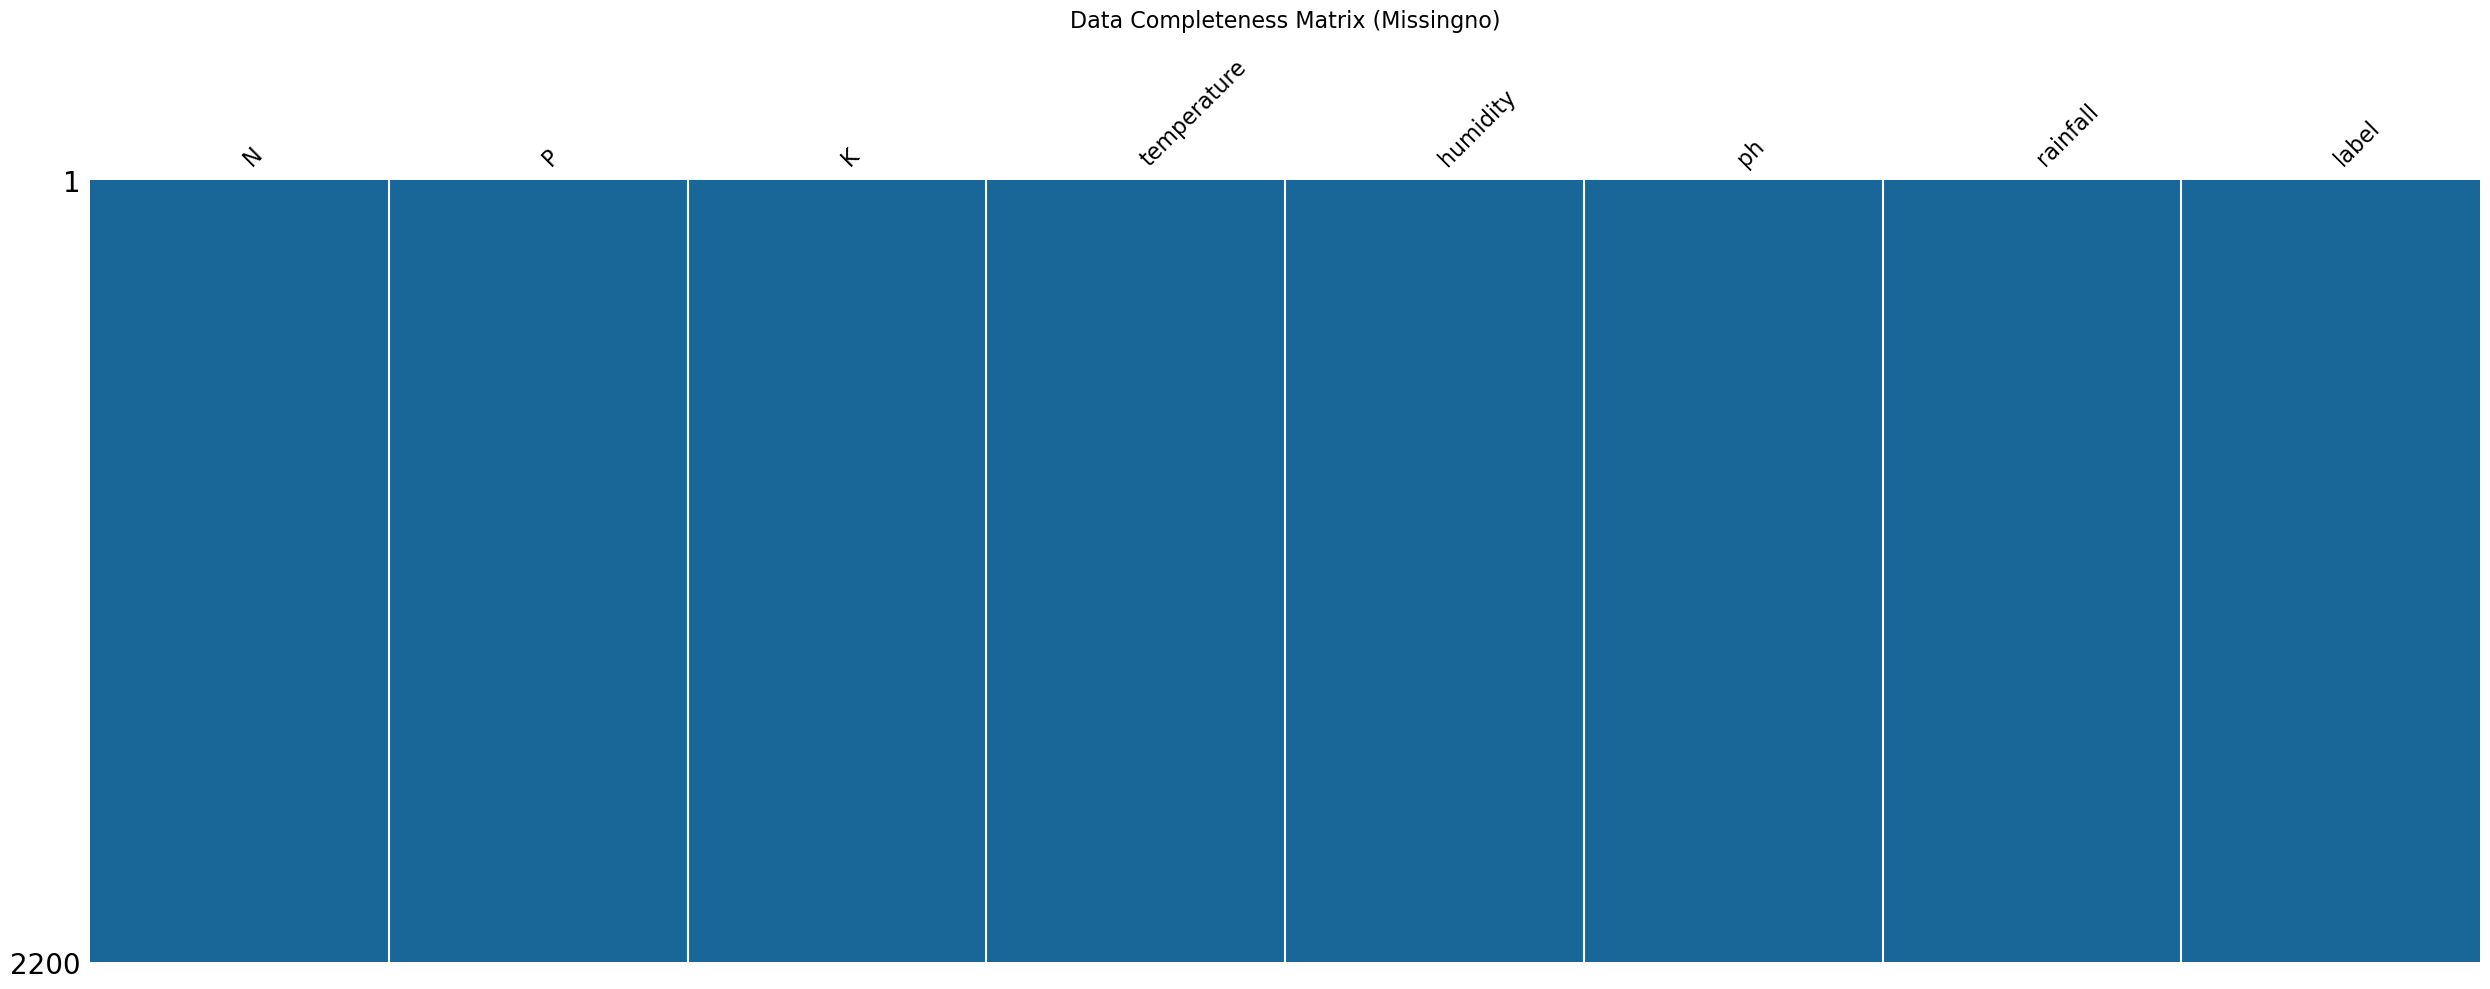

Missingness matrix plot successfully written to: ../reports/figures/00_missingness_matrix.png


In [17]:
# Create structural output path if missing
os.makedirs("../reports/figures", exist_ok=True)

# 1. Programmatic missing value checK
missing_summary = df.isnull().sum()
print("Missing Value Count per Column:")
print(missing_summary)

# 2. Visual missingness Matrix check
plt.figure(figsize=(10, 6))
msno.matrix(df, sparkline=False, color=(0.1,0.4,0.6))
plt.title("Data Completeness Matrix (Missingno)", fontsize=16, pad=20)
plt.tight_layout()

# Save the matrix plot
matrix_path = "../reports/figures/00_missingness_matrix.png"
plt.savefig(matrix_path, dpi=300)
plt.show()
print(f"Missingness matrix plot successfully written to: {matrix_path}")

#### Missing Values Analysis & Visual Insight
The programmatic check and the `missingno.matrix` plot confirm exactly **zero missing values** across all columns. The matrix presents as a solid, uninterrupted block of color, demonstrating 100% data density.

* **Strategic Production Caveat:** In an operational deployment, raw agricultural data flowing from field IoT soil sensors, manual probe logs, or remote weather APIs will invariably contain gaps, drops, or transmission timeouts. 
* **Implication:** The perfect completeness observed here strongly suggests a curated or synthetic benchmark environment. While excellent for baseline logic training, Rhea must construct fallback mechanisms (such as imputation or forward-fill logic) when deploying this model with live telemetry feeds.

In [10]:
# Evaluate and remove duplicate entries if present
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows successfully removed.")

Total Duplicate Rows Found: 0


#### Duplication Verification
The dataset contains **zero duplicate rows**, preserving a clean 1:1 row-to-observation mapping. This ensures that our downstream similarity matrices and class distributions remain unwarped by repeated entries.

In [11]:
# Check Initial data types 
print("Data types before casting:")
print(df.dtypes)

# cast target column to category for better memory handling and modelling   
df['label'] = df['label'].astype('category')

print("\n Data Types after casting")
print(df.dtypes)

Data types before casting:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

 Data Types after casting
N                 int64
P                 int64
K                 int64
temperature     float64
humidity        float64
ph              float64
rainfall        float64
label          category
dtype: object


### Data Type Verification
All the columns have the data types we'd expect. The soil nutrient columns (`N`, `P`, `K`) are stored as whole numbers, and the environmental columns (`temperature`, `humidity`, `ph`, `rainfall`) are stored as decimals. We also converted the `label` column from plain text to a categorical type — this makes later processing faster and keeps the crop options locked to the 22 valid classes.

In [12]:
# 1. Clean whitespace and casting Variation in labels
unique_labels = df['label'].unique()
print(f"Unique crop classes verified: {len(unique_labels)}")

# 2. check logical ranges for pH and non negative constraints
ph_bounds_valid = df['ph'].between(0, 14).all()
negatives_exist = (df[['N', 'P', 'K', 'temperature', 'humidity', 'rainfall']] < 0).any().any()

print(f"Are all pH values within valid agronomic limits (0-14)? {ph_bounds_valid}")
print(f"Are there any illegal negative sensor readings? {negatives_exist}")

Unique crop classes verified: 22
Are all pH values within valid agronomic limits (0-14)? True
Are there any illegal negative sensor readings? False


### Consistency Check Findings
The consistency sweep confirms uniform structural hygiene. The target crop labels possess zero trailing whitespace or irregular capitalization variations. Every reported pH value falls squarely inside the scientifically sound scale of 0 to 14, and no physically impossible negative numbers exist in the nutrient or climate attributes.

In [13]:
# Per-crop outlier scan using Interquartile Range (IQR) bounds within each unique crop group
outlier_records = []

for crop, group in df.groupby('label', observed=False):
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = group[col].quantile(0.25)
        Q3 = group[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identify outliers relative to this specific crop's baseline profile
        outliers = group[(group[col] < lower_bound) | (group[col] > upper_bound)]
        if not outliers.empty:
            outlier_records.append({
                'Crop': crop,
                'Feature': col,
                'Outlier Count': len(outliers)
            })

outlier_summary_df = pd.DataFrame(outlier_records)
if not outlier_summary_df.empty:
    print(outlier_summary_df.to_string(index=False))
else:
    print("No per-crop outliers identified via IQR bounds.")

No per-crop outliers identified via IQR bounds.


### Agronomic Rationale for Outlier Management

Outlier detection was performed **within each crop category** rather than across the entire dataset. This approach recognizes that every crop has its own natural growing conditions and nutrient requirements.

For example, rice typically requires substantially higher rainfall than many other crops. If all crops were analyzed together, these perfectly valid rainfall values could be incorrectly classified as statistical outliers simply because they differ from the overall dataset average. Such false positives would remove legitimate crop-specific characteristics from the data.

To avoid this, the Interquartile Range (IQR) method was applied separately to each crop. Every observation was therefore compared only against other samples of the same crop, ensuring that the analysis reflected each crop's expected agronomic profile.

The analysis found **no observations outside the IQR bounds within any crop group**. This indicates that the numerical features for each crop are internally consistent and do not exhibit unusually extreme values relative to other samples of the same crop.

**Strategic Decision:** Since no per-crop outliers were identified, no observations were removed. The dataset was retained in its entirety, preserving the natural variation present within each crop while maintaining data quality for downstream analysis and model development.

In [18]:
# Create structural output paths if missing, then export the clean dataframe
os.makedirs("../data/processed", exist_ok=True)
cleaned_data_path = "../data/processed/cleaned_crop_data.csv"
df.to_csv(cleaned_data_path, index=False)
print(f"Cleaned dataset successfully written to: {cleaned_data_path}")

Cleaned dataset successfully written to: ../data/processed/cleaned_crop_data.csv
